<a href="https://colab.research.google.com/github/nasywafunnisa/pengolahan-citra-digital/blob/main/PCD_weld_inspection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inspeksi Cacat Pengelasan — Deteksi Anomali Permukaan
**Model:** YOLOv8s-seg | **Task:** Instance Segmentation  
**Dataset:** Weld Defect (`images_bbox_mask/`) — format YOLO bbox

## 1. Install Dependencies

In [1]:
!pip install -q ultralytics albumentations PyYAML tqdm opencv-python-headless

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.1 MB/s eta 0:00:00


## 2. Import & Konfigurasi

In [2]:
import os
import shutil
import random
import math
import cv2
import numpy as np
import yaml
from pathlib import Path
from tqdm import tqdm
import albumentations as A
from ultralytics import YOLO

# ── Seed ──────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Path ──────────────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive")

RAW_DIR = Path("/content/drive/MyDrive/Colab Notebooks/images_bbox_mask")
OUT_DIR     = Path("/content/weld_dataset")    # split train/valid/test
AUG_DIR     = Path("/content/weld_augmented")  # setelah augmentasi
PROJECT_DIR = "/content/weld_runs"             # output training YOLO
RUN_NAME    = "yolov8s_seg_weld"

# ── Training config ───────────────────────────────────────
EPOCHS     = 80
IMG_SIZE   = 640
BATCH_SIZE = 16
DEVICE     = 0

# ── Kelas cacat ───────────────────────────────────────────
CLASS_NAMES = {
    0: "defect_0",
    1: "defect_1",
    2: "defect_2",
}

# ── Split ratio ───────────────────────────────────────────
TRAIN_RATIO = 0.8
VAL_RATIO   = 0.1
# Test = sisanya 0.1

print("✅ Config loaded")
print(f"   RAW_DIR  : {RAW_DIR}")
print(f"   Classes  : {list(CLASS_NAMES.values())}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive
✅ Config loaded
   RAW_DIR  : /content/drive/MyDrive/Colab Notebooks/images_bbox_mask
   Classes  : ['defect_0', 'defect_1', 'defect_2']


## 3. Split Train / Valid / Test

In [3]:
# Ambil semua stem dari .jpg di folder raw
all_stems = sorted(set(p.stem for p in RAW_DIR.glob("*.jpg")))
print(f"Total gambar ditemukan: {len(all_stems)}")

# Shuffle & split
random.shuffle(all_stems)
n       = len(all_stems)
n_train = int(n * TRAIN_RATIO)
n_val   = int(n * VAL_RATIO)

splits = {
    "train": all_stems[:n_train],
    "valid": all_stems[n_train:n_train + n_val],
    "test" : all_stems[n_train + n_val:],
}

# Copy ke folder split
for split, stems in splits.items():
    (OUT_DIR / split / "images").mkdir(parents=True, exist_ok=True)
    (OUT_DIR / split / "labels").mkdir(parents=True, exist_ok=True)
    for stem in tqdm(stems, desc=f"Copying {split}"):
        src_img = RAW_DIR / f"{stem}.jpg"
        src_lbl = RAW_DIR / f"{stem}.txt"
        if src_img.exists():
            shutil.copy2(src_img, OUT_DIR / split / "images" / f"{stem}.jpg")
        if src_lbl.exists():
            shutil.copy2(src_lbl, OUT_DIR / split / "labels" / f"{stem}.txt")

for split, stems in splits.items():
    n_img = len(list((OUT_DIR / split / "images").glob("*.jpg")))
    print(f"  {split:5s}: {n_img} gambar")

Total gambar ditemukan: 1619


Copying test: 100%|██████████| 163/163 [00:01<00:00, 137.61it/s]

  train: 1295 gambar
  valid: 161 gambar
  test : 163 gambar


## 4. Buat data.yaml

In [4]:
data_yaml = {
    "path" : str(OUT_DIR.resolve()),
    "train": "train/images",
    "val"  : "valid/images",
    "test" : "test/images",
    "nc"   : len(CLASS_NAMES),
    "names": list(CLASS_NAMES.values()),
}

yaml_path = OUT_DIR / "data.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f"✅ data.yaml disimpan di: {yaml_path}")
print(yaml.dump(data_yaml))

✅ data.yaml disimpan di: /content/weld_dataset/data.yaml
names:
- defect_0
- defect_1
- defect_2
nc: 3
path: /content/weld_dataset
test: test/images
train: train/images
val: valid/images



## 5. Augmentasi Data (Class-Biased)

In [5]:
# Hitung distribusi kelas di train set
obs_counts = {i: 0 for i in CLASS_NAMES}
for lbl_path in (OUT_DIR / "train" / "labels").glob("*.txt"):
    with open(lbl_path) as f:
        for line in f:
            cls_id = int(line.split()[0])
            if cls_id in obs_counts:
                obs_counts[cls_id] += 1

print("Distribusi kelas di train set:")
for cls_id, cnt in obs_counts.items():
    print(f"  [{cls_id}] {CLASS_NAMES[cls_id]:>15s}: {cnt} anotasi")

# Multiplier augmentasi otomatis berdasarkan distribusi kelas
TARGET_COUNT   = 3000
AUG_MULTIPLIER = {
    cls: max(1, math.ceil(TARGET_COUNT / max(cnt, 1)))
    for cls, cnt in obs_counts.items()
}
print("\nMultiplier augmentasi per kelas:")
for cls_id, mult in AUG_MULTIPLIER.items():
    print(f"  [{cls_id}] {CLASS_NAMES[cls_id]:>15s}: x{mult}")

Distribusi kelas di train set:
  [0]        defect_0: 881 anotasi
  [1]        defect_1: 1522 anotasi
  [2]        defect_2: 1294 anotasi

Multiplier augmentasi per kelas:
  [0]        defect_0: x4
  [1]        defect_1: x2
  [2]        defect_2: x3


In [6]:
# Pipeline augmentasi
HEAVY_CLASSES = {cls for cls, mult in AUG_MULTIPLIER.items() if mult >= 5}

def base_aug():
    """Augmentasi ringan untuk kelas yang cukup seimbang."""
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.RandomRotate90(p=0.4),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=20, p=0.4),
    ])

def heavy_aug():
    """Augmentasi agresif untuk kelas minoritas."""
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=30, p=0.7,
                           border_mode=cv2.BORDER_REFLECT_101),
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.6),
        A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=30, p=0.5),
        A.GaussNoise(var_limit=(10, 50), p=0.4),
        A.GaussianBlur(blur_limit=(3, 5), p=0.3),
        A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.4),
        A.Sharpen(alpha=(0.2, 0.5), lightness=(0.5, 1.0), p=0.3),
        A.GridDistortion(num_steps=5, distort_limit=0.2, p=0.3),
    ])

def get_augmenter(dominant_cls):
    return heavy_aug() if dominant_cls in HEAVY_CLASSES else base_aug()

def dominant_class(label_path):
    counts = {}
    with open(label_path) as f:
        for line in f:
            cls = int(line.split()[0])
            counts[cls] = counts.get(cls, 0) + 1
    return max(counts, key=counts.get) if counts else 0

print(f"✅ Kelas heavy aug: {[CLASS_NAMES[c] for c in HEAVY_CLASSES]}")

✅ Kelas heavy aug: []


In [7]:
# Jalankan augmentasi pada train set
def augment_split(src_split, dst_split):
    img_dst = dst_split / "images"
    lbl_dst = dst_split / "labels"
    img_dst.mkdir(parents=True, exist_ok=True)
    lbl_dst.mkdir(parents=True, exist_ok=True)

    for img_fp in tqdm(sorted((src_split / "images").glob("*.jpg")), desc="Augmenting train"):
        stem   = img_fp.stem
        lbl_fp = src_split / "labels" / f"{stem}.txt"

        shutil.copy2(img_fp, img_dst / img_fp.name)
        if not lbl_fp.exists():
            continue
        shutil.copy2(lbl_fp, lbl_dst / f"{stem}.txt")

        dom  = dominant_class(lbl_fp)
        mult = AUG_MULTIPLIER.get(dom, 1)
        if mult <= 1:
            continue

        augmenter = get_augmenter(dom)
        img = cv2.imread(str(img_fp))
        if img is None:
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        for i in range(mult - 1):
            aug_img  = cv2.cvtColor(augmenter(image=img_rgb)["image"], cv2.COLOR_RGB2BGR)
            aug_stem = f"{stem}_aug{i:03d}"
            cv2.imwrite(str(img_dst / f"{aug_stem}.jpg"), aug_img)
            shutil.copy2(lbl_fp, lbl_dst / f"{aug_stem}.txt")

def copy_split(src, dst):
    for sub in ("images", "labels"):
        (dst / sub).mkdir(parents=True, exist_ok=True)
        for fp in (src / sub).iterdir():
            shutil.copy2(fp, dst / sub / fp.name)

augment_split(OUT_DIR / "train", AUG_DIR / "train")
print("Copying valid & test...")
copy_split(OUT_DIR / "valid", AUG_DIR / "valid")
copy_split(OUT_DIR / "test",  AUG_DIR / "test")

# data.yaml untuk dataset augmentasi
aug_yaml_data = {
    "path" : str(AUG_DIR.resolve()),
    "train": "train/images",
    "val"  : "valid/images",
    "test" : "test/images",
    "nc"   : len(CLASS_NAMES),
    "names": list(CLASS_NAMES.values()),
}
aug_yaml_path = AUG_DIR / "data.yaml"
with open(aug_yaml_path, "w") as f:
    yaml.dump(aug_yaml_data, f, default_flow_style=False)

for split in ("train", "valid", "test"):
    n_img = len(list((AUG_DIR / split / "images").glob("*.jpg")))
    print(f"  {split:5s}: {n_img} gambar")
print(f"\n✅ Dataset augmentasi siap: {AUG_DIR}")

Augmenting train: 100%|██████████| 1295/1295 [00:23<00:00, 55.63it/s]

Copying valid & test...
  train: 3475 gambar
  valid: 161 gambar
  test : 163 gambar

✅ Dataset augmentasi siap: /content/weld_augmented


## 6. Training YOLOv8s-seg

In [8]:
# Class weights (inverse-frequency)
total  = sum(obs_counts.values())
freq   = {c: v / (total + 1e-9) for c, v in obs_counts.items()}
raw_w  = {c: 1.0 / (f + 1e-9)   for c, f in freq.items()}
mean_w = sum(raw_w.values()) / len(raw_w)
weights = [raw_w[c] / mean_w for c in sorted(raw_w)]

print("Class weights (inverse-frequency, normalized):")
for cls_id, w in zip(sorted(CLASS_NAMES), weights):
    print(f"  [{cls_id}] {CLASS_NAMES[cls_id]:>15s}: {w:.3f}")

Class weights (inverse-frequency, normalized):
  [0]        defect_0: 1.328
  [1]        defect_1: 0.768
  [2]        defect_2: 0.904


In [9]:
# Hapus gambar yang label-nya kosong atau tidak ada
removed = 0
for split in ("train", "valid", "test"):
    img_dir = AUG_DIR / split / "images"
    lbl_dir = AUG_DIR / split / "labels"
    for img_fp in list(img_dir.glob("*.jpg")):
        lbl_fp = lbl_dir / f"{img_fp.stem}.txt"
        # Hapus jika label tidak ada atau kosong
        if not lbl_fp.exists() or lbl_fp.stat().st_size == 0:
            img_fp.unlink()
            if lbl_fp.exists():
                lbl_fp.unlink()
            removed += 1

print(f"✅ Removed {removed} gambar tanpa label")

# Hapus cache lama supaya YOLO scan ulang
for cache in AUG_DIR.rglob("*.cache"):
    cache.unlink()
print("✅ Cache lama dihapus")

✅ Removed 0 gambar tanpa label
✅ Cache lama dihapus


In [10]:
model = YOLO("yolov8s.pt")  # download otomatis

results = model.train(
    data        = str(aug_yaml_path),
    epochs      = EPOCHS,
    imgsz       = IMG_SIZE,
    batch       = BATCH_SIZE,
    device      = DEVICE,
    project     = PROJECT_DIR,
    name        = RUN_NAME,
    seed        = SEED,
    patience    = 20,
    save        = True,
    save_period = 10,
    amp         = True,
    mosaic      = 1.0,
    mixup       = 0.1,
    copy_paste  = 0.1,
    degrees     = 10.0,
    translate   = 0.1,
    scale       = 0.5,
    flipud      = 0.3,
    fliplr      = 0.5,
    hsv_h       = 0.015,
    hsv_s       = 0.7,
    hsv_v       = 0.4,
    box         = 7.5,
    cls         = 0.5,
    dfl         = 1.5,
)

best_weights = f"{PROJECT_DIR}/{RUN_NAME}/weights/best.pt"
print(f"\n✅ Training selesai!")
print(f"   Best weights: {best_weights}")

Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/weld_augmented/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_seg_weld, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, 

## 7. Evaluasi Model

In [11]:
model_eval = YOLO(best_weights)
metrics = model_eval.val(
    data   = str(aug_yaml_path),
    imgsz  = IMG_SIZE,
    device = DEVICE,
    split  = "test",
)

print("\n── Hasil Evaluasi (Test Set) ──")
print(f"  mAP@0.5      : {metrics.box.map50:.4f}")
print(f"  mAP@0.5:0.95 : {metrics.box.map:.4f}")
print(f"  Precision    : {metrics.box.mp:.4f}")
print(f"  Recall       : {metrics.box.mr:.4f}")

Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 59.1±64.5 MB/s, size: 50.1 KB)
val: Scanning /content/weld_augmented/test/labels... 163 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 163/163 581.3it/s 0.3s
val: New cache created: /content/weld_augmented/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 2.1it/s 5.2s
                   all        163        468      0.617       0.66      0.656      0.382
              defect_0         69        101      0.658      0.837      0.763      0.496
              defect_1        102        211      0.686      0.758      0.761      0.435
              defect_2         73        156      0.508      0.385      0.444      0.215
Speed: 7.1ms preprocess, 10.4ms inference, 0.0ms loss, 2.7ms postprocess 

## 8. Inferensi & Visualisasi

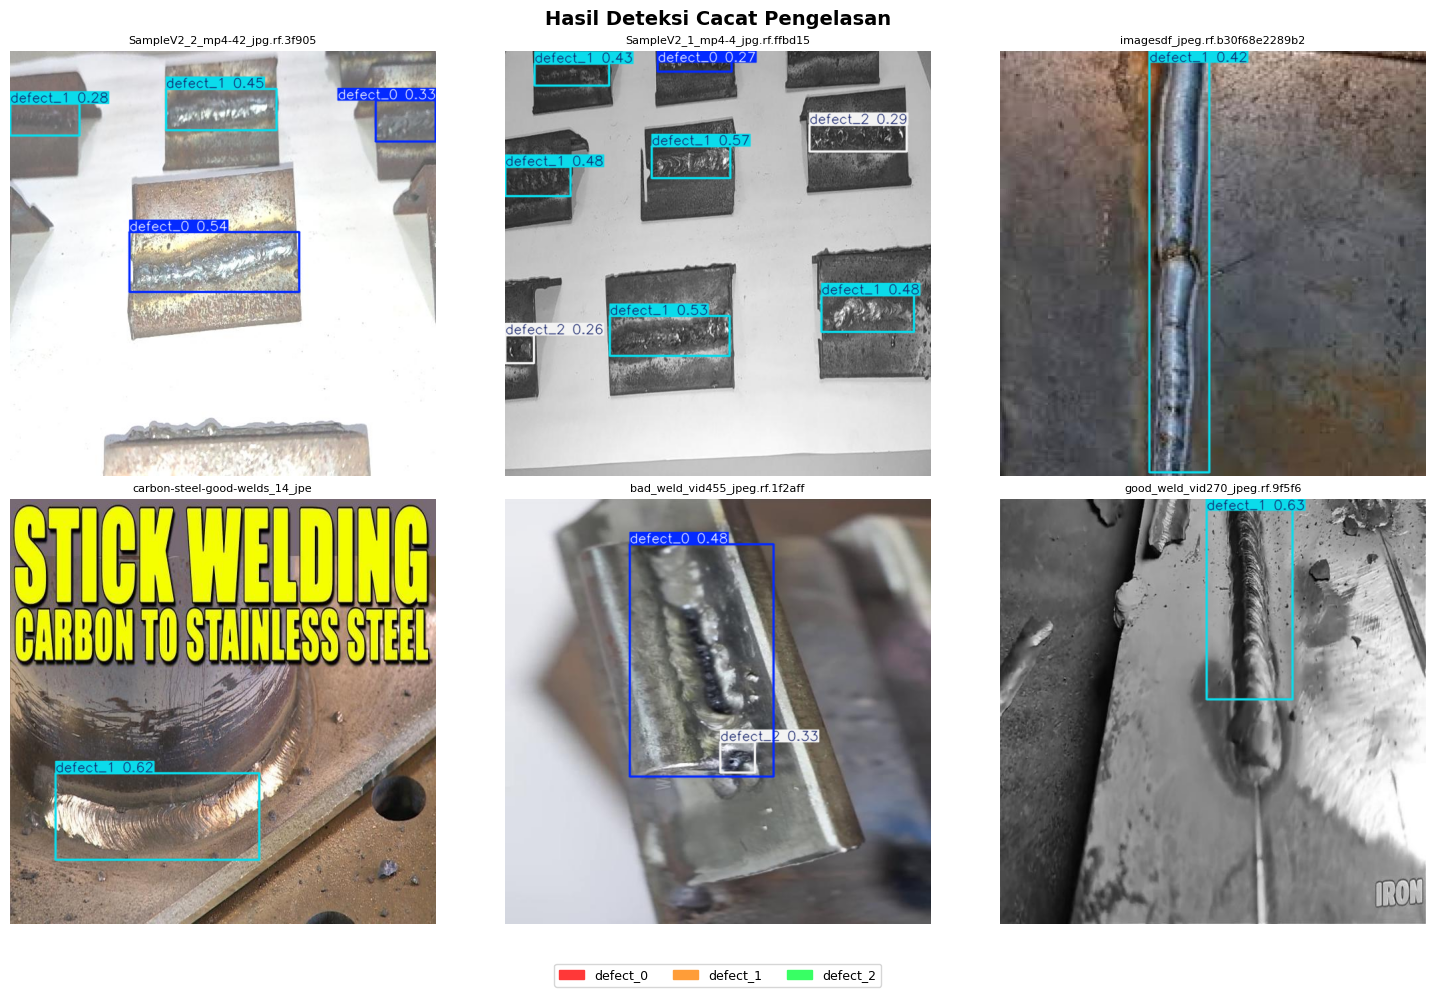

✅ Visualisasi disimpan: /content/hasil_deteksi_weld.png


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

test_images = list((AUG_DIR / "test" / "images").glob("*.jpg"))[:6]

COLORS = [
    (255,  56,  56),  # defect_0
    (255, 157,  56),  # defect_1
    ( 56, 255, 100),  # defect_2
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Hasil Deteksi Cacat Pengelasan", fontsize=14, fontweight="bold")

for ax, img_path in zip(axes.flatten(), test_images):
    result  = model_eval.predict(str(img_path), conf=0.25, verbose=False)[0]
    img_bgr = cv2.imread(str(img_path))
    vis     = result.plot(img=img_bgr.copy())
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(img_path.name[:30], fontsize=8)
    ax.axis("off")

patches = [mpatches.Patch(color=[c/255 for c in COLORS[i]], label=CLASS_NAMES[i])
           for i in CLASS_NAMES]
fig.legend(handles=patches, loc="lower center", ncol=len(CLASS_NAMES),
           fontsize=9, framealpha=0.8)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("/content/hasil_deteksi_weld.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Visualisasi disimpan: /content/hasil_deteksi_weld.png")

## 9. Simpan Model

In [13]:
model_eval.export(format="onnx", imgsz=IMG_SIZE)
print(f"✅ Best weights : {best_weights}")
print(f"   ONNX export  : {best_weights.replace('.pt', '.onnx')}")

Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/weld_runs/yolov8s_seg_weld/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (21.5 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 299ms
Prepared 4 packages in 1.82s
Installed 4 packages in 286ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.27.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 3.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 5.7s, saved as '/content/wel

## 10. Confusion matrix

Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1595.1±700.0 MB/s, size: 64.5 KB)
val: Scanning /content/weld_augmented/valid/labels.cache... 161 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 161/161 37.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 2.3it/s 4.7s
                   all        161        418      0.707       0.67      0.712      0.387
Speed: 5.0ms preprocess, 9.9ms inference, 0.0ms loss, 4.0ms postprocess per image
Results saved to /content/runs/detect/val-2
       HASIL EVALUASI MODEL
  mAP@0.5        : 0.7117
  mAP@0.5:0.95   : 0.3874
  Precision      : 0.7073
  Recall         : 0.6699

Per Kelas:
  defect_0     — AP50: 0.8778
  defect_1     — AP50: 0.7930
  defect_2     — AP50: 0.4643


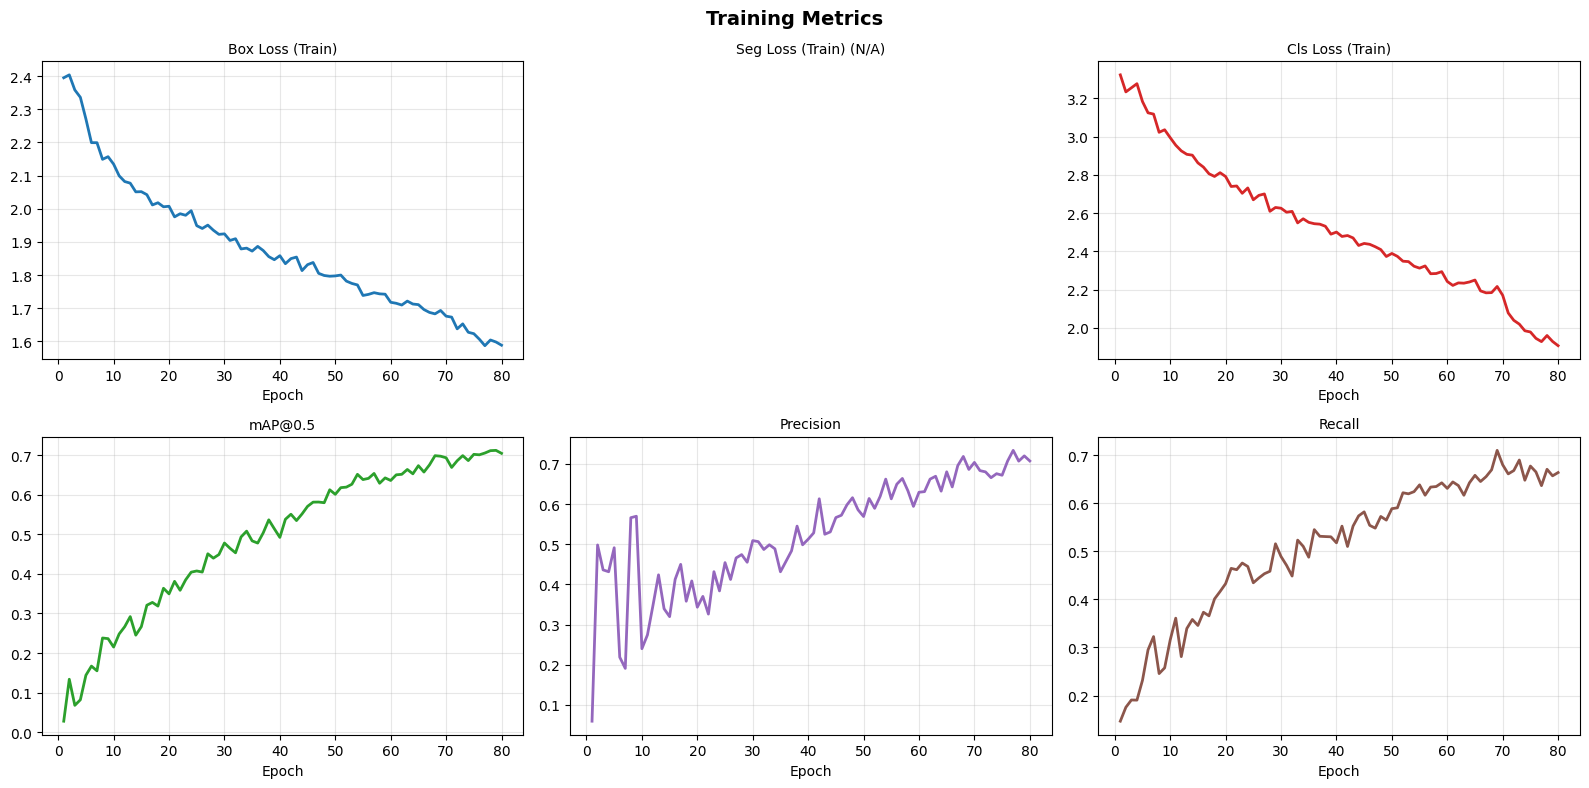

Grafik disimpan: /content/training_metrics.png


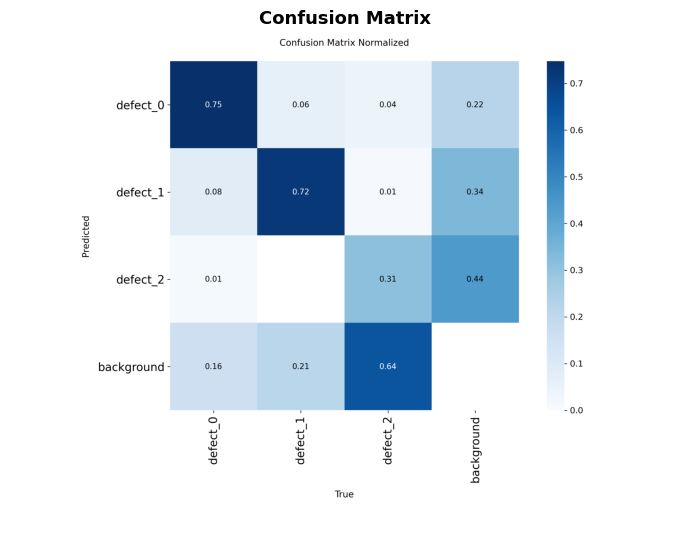

Confusion matrix disimpan: /content/confusion_matrix.png


In [14]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

RUNS_PATH = Path(f"{PROJECT_DIR}/{RUN_NAME}")

# ── 1. Metrik numerik ──────────────────────────────────────
model_eval = YOLO(str(RUNS_PATH / "weights/best.pt"))
metrics = model_eval.val(data=str(AUG_DIR / "data.yaml"), verbose=False)

print("=" * 40)
print("       HASIL EVALUASI MODEL")
print("=" * 40)
print(f"  mAP@0.5        : {metrics.box.map50:.4f}")
print(f"  mAP@0.5:0.95   : {metrics.box.map:.4f}")
print(f"  Precision      : {metrics.box.mp:.4f}")
print(f"  Recall         : {metrics.box.mr:.4f}")
print("=" * 40)

# Per kelas
print("\nPer Kelas:")
for i, name in CLASS_NAMES.items():
    print(f"  {name:12s} — AP50: {metrics.box.ap50[i]:.4f}")

# ── 2. Grafik loss & metrik dari hasil training ────────────
results_csv = RUNS_PATH / "results.csv"
if results_csv.exists():
    import pandas as pd
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    fig.suptitle("Training Metrics", fontsize=14, fontweight="bold")

    plots = [
        ("train/box_loss",  "Box Loss (Train)",      "tab:blue"),
        ("train/seg_loss",  "Seg Loss (Train)",      "tab:orange"),
        ("train/cls_loss",  "Cls Loss (Train)",      "tab:red"),
        ("metrics/mAP50(B)","mAP@0.5",               "tab:green"),
        ("metrics/precision(B)", "Precision",        "tab:purple"),
        ("metrics/recall(B)",    "Recall",           "tab:brown"),
    ]

    for ax, (col, title, color) in zip(axes.flatten(), plots):
        if col in df.columns:
            ax.plot(df["epoch"], df[col], color=color, linewidth=2)
            ax.set_title(title, fontsize=10)
            ax.set_xlabel("Epoch")
            ax.grid(True, alpha=0.3)
        else:
            ax.set_title(f"{title} (N/A)", fontsize=10)
            ax.axis("off")

    plt.tight_layout()
    plt.savefig("/content/training_metrics.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Grafik disimpan: /content/training_metrics.png")

# ── 3. Confusion Matrix ────────────────────────────────────
conf_matrix_path = RUNS_PATH / "confusion_matrix_normalized.png"
if not conf_matrix_path.exists():
    conf_matrix_path = RUNS_PATH / "confusion_matrix.png"

if conf_matrix_path.exists():
    fig, ax = plt.subplots(figsize=(7, 6))
    img = mpimg.imread(str(conf_matrix_path))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title("Confusion Matrix", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("/content/confusion_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Confusion matrix disimpan: /content/confusion_matrix.png")
else:
    print("Confusion matrix tidak ditemukan, generate manual...")
    model_eval.val(
        data=str(AUG_DIR / "data.yaml"),
        plots=True,
        save_dir=str(RUNS_PATH)
    )